**LOGISTIC REGRESSION**


---

Initial implementation by - **Rina Peshori**

Extended with additional evaluation metrices (ROC Curve, F1-Score, etc.) # New Section


In [ ]:
#############################
#       IMPORT LIBRARIES    #
#############################

import numpy as np
import pandas as pd
import os

In [ ]:
NUM_TARGET_CLASSES = 3
ITERATIONS = 5000
ETA = 0.01
THRESHOLD = 1e-4

In [ ]:
#############################
#  LOAD OR PREPARE DATASET  #
#############################

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#############################
#  LOAD OR PREPARE DATASET  #
#############################

# Github
# X_train_path = "data/processed_data/X_train_scaled.csv"
# y_train_path = "data/processed_data/y_train.csv"
# X_test_path = "data/processed_data/X_test_scaled.csv"
# y_test_path = "data/processed_data/y_test.csv"

# Google Colab
X_train_path = "/content/drive/MyDrive/ML Group Project CSCI 635/data/processed_data/X_train_scaled.csv"
y_train_path = "/content/drive/MyDrive/ML Group Project CSCI 635/data/processed_data/y_train.csv"
X_test_path = "/content/drive/MyDrive/ML Group Project CSCI 635/data/processed_data/X_test_scaled.csv"
y_test_path = "/content/drive/MyDrive/ML Group Project CSCI 635/data/processed_data/y_test.csv"

X_train = pd.read_csv(X_train_path)
y_train = pd.read_csv(y_train_path)
X_test = pd.read_csv(X_test_path)
y_test = pd.read_csv(y_test_path)

print("Training X shape:", X_train.shape)
print("Training y shape:", y_train.shape)
print("Test X shape:", X_test.shape)
print("Test y shape:", y_test.shape)

Training X shape: (1600, 12)
Training y shape: (1600, 1)
Test X shape: (400, 12)
Test y shape: (400, 1)


In [ ]:
#############################
# SIGMOID AND LOSS FUNCTION #
#############################

def sigmoid(z):
  z = np.clip(z, -500, 500)
  return 1 / (1 + np.exp(-z))

def compute_loss(y, p):
  epsilon = 1e-15
  p = np.clip(p, epsilon, 1 - epsilon)
  return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

In [ ]:
#############################
#     PREPARE MATRICES      #
#############################

X_train_matrix = np.hstack((np.ones((len(X_train), 1)), X_train.values))
X_test_matrix  = np.hstack((np.ones((len(X_test), 1)), X_test.values))

y_train_matrix = y_train.values.reshape(-1)
y_test_matrix = y_test.values.reshape(-1)

print("Train matrix shape:", X_train_matrix.shape)
print("Test matrix shape:", X_test_matrix.shape)

Train matrix shape: (1600, 13)
Test matrix shape: (400, 13)


In [ ]:
#############################
#  1 v/s REST LOGISTIC REG. #
#############################

beta_arr = []

for k in range(NUM_TARGET_CLASSES):
  print(f"Training class {k} v/s rest")

  y = (y_train_matrix == k).astype(int)
  beta = np.zeros(X_train_matrix.shape[1])
  prev_loss = float("inf")

  for i in range(1, ITERATIONS+1):
    p = sigmoid(np.dot(X_train_matrix, beta))
    loss = compute_loss(y, p)

    if abs(prev_loss - loss) < THRESHOLD:
      print(f"Converged at iteration {i}")
      break
    prev_loss = loss

    num_pos = np.sum(y == 1)
    num_neg = np.sum(y == 0)
    pos_weight = len(y) / (2 * num_pos)
    neg_weight = len(y) / (2 * num_neg)
    weights = np.where(y==1, pos_weight, neg_weight)

    transposed_X = X_train_matrix.T
    weighted = weights * (p - y)
    gradient = np.dot(transposed_X, weighted)

    beta = beta - ETA * gradient

    if i % 500 == 0:
      print(f"Iteration {i}, loss: {loss}")

  beta_arr.append(beta)

Training class 0 v/s rest
Converged at iteration 22
Training class 1 v/s rest
Iteration 500, loss: 1.3805407626117383
Iteration 1000, loss: 2.9076230895619024
Iteration 1500, loss: 1.204118338975115
Iteration 2000, loss: 1.341761856998432
Iteration 2500, loss: 3.089242372798012
Iteration 3000, loss: 1.2120828149672862
Iteration 3500, loss: 1.251524916863545
Iteration 4000, loss: 3.055129774359574
Iteration 4500, loss: 0.9884278272526228
Iteration 5000, loss: 1.0488586463979654
Training class 2 v/s rest
Iteration 500, loss: 0.017362860971411032
Iteration 1000, loss: 0.11850755831938833
Iteration 1500, loss: 0.12107853453123851
Iteration 2000, loss: 0.07849138273715507
Iteration 2500, loss: 0.061289158046114366
Iteration 3000, loss: 0.052124600665813724
Iteration 3500, loss: 0.04493582305161356
Iteration 4000, loss: 0.039224376682721496
Iteration 4500, loss: 0.034618916242201044
Iteration 5000, loss: 0.030831647598486094


In [ ]:
#############################
#        PREDICTION         #
#############################

probabilities = []

for beta in beta_arr:
  p = sigmoid(np.dot(X_test_matrix, beta))
  probabilities.append(p)

probabilities = np.array(probabilities)
y_pred = np.argmax(probabilities, axis=0)

In [ ]:
#############################
#          ACCURACY         #
#############################

accuracy = np.mean(y_test_matrix == y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9425


In [ ]:
#############################
#     PER CLASS ACCURACY    #
#############################

for i in range(NUM_TARGET_CLASSES):
  k = (y_test_matrix == i)
  acc = np.mean(y_pred[k] == i)
  print(f"Class {i} accuracy: {acc:.4f}")

Class 0 accuracy: 0.9559
Class 1 accuracy: 0.9172
Class 2 accuracy: 1.0000


In [ ]:
#############################
#     CONFUSION MATRIX      #
#############################

cm = pd.crosstab(y_test_matrix, y_pred, rownames=['Actual'], colnames=['Predicted'])
display(cm)

Predicted,0,1,2
Actual,,,
0,195,9,0
1,6,155,8
2,0,0,27


In [ ]:
#############################
#  PRECISION / RECALL / F1  #
#############################

from sklearn.metrics import classification_report
print(classification_report(y_test_matrix, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.96      0.96       204
           1       0.95      0.92      0.93       169
           2       0.77      1.00      0.87        27

    accuracy                           0.94       400
   macro avg       0.90      0.96      0.92       400
weighted avg       0.95      0.94      0.94       400



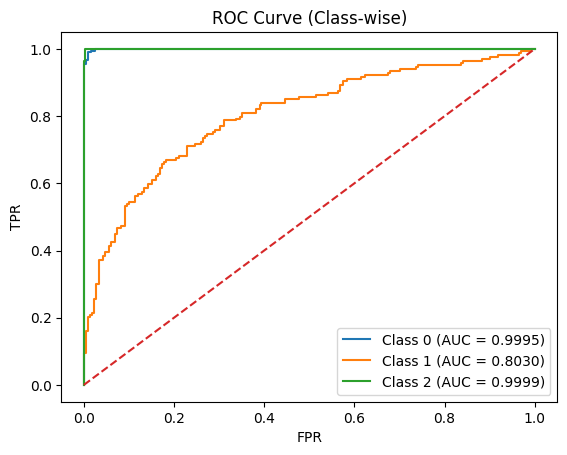

In [ ]:
#############################
#  ROC CURVE (CLASS-WISE)   #
#############################

from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize

y_test_one_hot = label_binarize(y_test_matrix, classes=[0, 1, 2])
probs = probabilities.T

for i in range(NUM_TARGET_CLASSES):
    fpr, tpr, _ = roc_curve(y_test_one_hot[:, i], probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.4f})")

plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve (Class-wise)")
plt.legend()
plt.show()

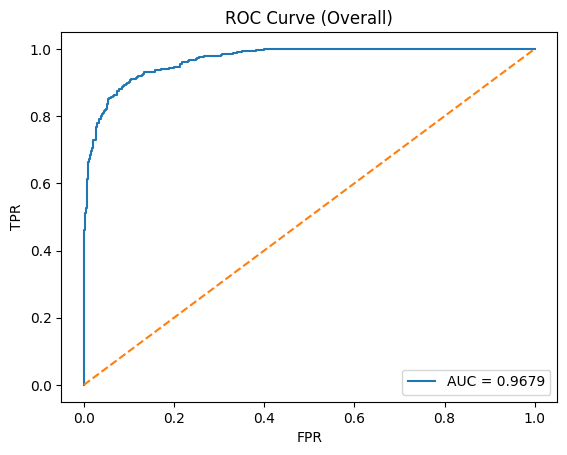

In [ ]:
#############################
#    ROC CURVE (OVERALL)    #
#############################

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

probs = probabilities.T
fpr, tpr, _ = roc_curve(y_test_one_hot.ravel(), probs.ravel())
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve (Overall)")
plt.legend()
plt.show()